Author: Romell Dominguez

Role: Data Scientist

Email: romell.dominguez@globant.com

GitHub: @romellfudi

Description:
This file contains the code for a POC CVs that does find the most similar candidates to a given query.

Date: October 20, 2023
License: MIT License

In [ ]:
%%capture
!pip install -q langchain pydantic python-dotenv openai pypdf tiktoken faiss-cpu kor streamlit gradio

**Run the following cell if you has the file in your drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cp /content/drive/MyDrive/_openai/.env /content/.env
%cd /content/

Mounted at /content/drive
/content


**Uncomment the following cell in case you do not have the file in the drive. After that, introduce your API key.**

In [ ]:
# %%writefile .env
# OPENAI_API_KEY="sk-"  #@param {type: "string"}

In [ ]:
#@title Download the FAISS db
%%capture
!gdown 1ubxp101J2pwlCAMPqjix73ayMiTStxLh -O faiss_merged.zip
!unzip -o faiss_merged.zip

In [ ]:
%%writefile candidates.py
from typing import List, Dict, Optional

from langchain.output_parsers import PydanticOutputParser
from langchain.prompts import PromptTemplate

from pydantic import BaseModel, Field, validator

class DocumentInput(BaseModel):
    question: str = Field(description="An extended and useful question")
    # format_answer: str = Field(description="format how should answer the question")

class Candidate(BaseModel):
    name: str = Field(description="name of the candidate")
    # inference
    genre: Optional[str] = Field(description="infer the gender of the candidate",
                      #  examples=[("f", "Female"), ("m", "Male")],
                      #  json_schema_extra={
                      #       'examples': ['male',"female"],
                      #   }
                       )
    address: str  = Field(description="address of the candidate",)
    phone: Optional[str] = Field(description="phone number of the candidate")
    # inferences
    hard_skills: List[str] = Field(description="list of hard skills of the candidate has")
    soft_skills: List[str] = Field(description="list of soft skills of the candidate has")
    # skills: Optional[List[str]] = Field(description="list of skills of the candidate has")

class Result(BaseModel):
    candidates: List[Candidate]

    # @validator("candidates", pre=True)
    # def validate_cities(cls, v):
    #     for candidate in v:
    #         skills = candidate.skills
    #         if not skills:
    #             raise ValueError(f"'skills' is required for {candidate.name}")
    #     return v


Writing candidates.py


# Streamlit

In [ ]:
%%writefile app.py
# Import necessary libraries
import os
import time
import json
import tempfile
import streamlit as st
from dotenv import load_dotenv
import openai

# Import Langchain modules
from langchain.agents import initialize_agent, AgentType, Tool
from langchain.callbacks import StreamlitCallbackHandler
from langchain.chains import SimpleSequentialChain, RetrievalQA
from langchain.memory import ConversationBufferMemory
from langchain.text_splitter import CharacterTextSplitter
from langchain.chat_models import ChatOpenAI
from langchain.document_loaders import PyPDFLoader
from langchain.prompts import PromptTemplate
from langchain.output_parsers import PydanticOutputParser
from langchain.embeddings.openai import OpenAIEmbeddings
from langchain.vectorstores import FAISS

from kor import from_pydantic, create_extraction_chain
from candidates import DocumentInput, Result

# Load environment variables from a .env file
load_dotenv()

st.title("PoC CVs Chat Assistant")
st.write("""
👋 Welcome to the 'PoC CVs Chat Assistant'. 👋

Your personal CV-solving chat assistant. 👨‍💻

The pre-loaded knowledge database was ingested with this [CVs](https://drive.google.com/file/d/120VRjt801ngFObCqU6KgJKuleaKGEd1N/view?usp=sharing) 📁
""")


# Get the user's prompt input
user_prompt = st.chat_input("Who candidate has knowledge about laws and regulations")

# Initialize chat history if it doesn't already exist
if "messages" not in st.session_state:
    st.session_state.messages = []


# Initialize the OpenAI language model and search tool
llm = ChatOpenAI(
    model_name="gpt-3.5-turbo",
    temperature=0,
    max_tokens=1000,
    frequency_penalty=0,
    presence_penalty=0,
    top_p=1.0,
)

schema, validator = from_pydantic(Result)
candidate_chain = create_extraction_chain(
    llm, schema, encoder_or_encoder_class="json", validator=validator
)
embeddings = OpenAIEmbeddings()
parser = PydanticOutputParser(pydantic_object=Result)
knowledge_database = FAISS.load_local('faiss_merged/', embeddings)
text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=0)
retriever = knowledge_database.as_retriever(search_kwargs={'k': 3}) # 'fetch_k': 30, filter
chain_qa = RetrievalQA.from_chain_type(llm=llm, retriever=retriever)
overall_chain = SimpleSequentialChain(chains=[chain_qa, candidate_chain], verbose=True)

tools = []
tools.append(
    Tool(
        args_schema = DocumentInput,
        output_schema = Result,
        name="curriculum_vitae",
        description=f"useful when you want to ask about candidates",
        func=overall_chain.run,
    )
)

if "memory" not in st.session_state:
    st.session_state.memory = ConversationBufferMemory(memory_key="chat_history", input_key='input', output_key="output")

agent = initialize_agent(
    agent=AgentType.OPENAI_FUNCTIONS,
    tools=tools,
    llm=llm,
    verbose=True,
    return_intermediate_steps=True,
    memory = st.session_state.memory,
)


@st.cache_resource(ttl="1h")
def add_more_context_in_kdb(uploaded_files):
    docs = []
    temp_dir = tempfile.TemporaryDirectory()
    for file in uploaded_files:
        temp_filepath = os.path.join(temp_dir.name, file.name)
        with open(temp_filepath, "wb") as f:
            f.write(file.getvalue())
        loader = PyPDFLoader(temp_filepath)
        docs.extend(loader.load())

    doc_faiss = FAISS.from_documents(docs, embeddings)
    knowledge_database.merge_from(doc_faiss)
    return knowledge_database

uploaded_files = st.file_uploader("Upload CVs files", type=["pdf"], accept_multiple_files=True)

if uploaded_files:
    # st.stop()
    knowledge_database = add_more_context_in_kdb(uploaded_files)

method = st.radio(
    "What method would you like to use?",
    ["***Agent***", "***Prompt***"],
    captions = ["Use langchain agent", "Only pass the most similar into prompt"],
    horizontal=True)


# Display previous chat messages from history
for message in st.session_state.messages:
    with st.chat_message(message["role"]):
        st.markdown(message["content"])

def ask_to_chatbot(user_intent, k=2, model: str = "gpt-3.5-turbo"):
    global faiss
    docs = knowledge_database.similarity_search(user_intent, k=k)
    context = ' '.join([doc.page_content for doc in docs])
    prompt = PromptTemplate(
      template="Answer the user query, use the context:{context}.\n{format_instructions}\n{query}\n",
      input_variables=["query"],
      partial_variables={"format_instructions": parser.get_format_instructions(), "context": context},)
    messages = [{"role": "user", "content": prompt.format_prompt(query=user_intent).to_string()}]
    response = openai.ChatCompletion.create(
        model = model,
        messages=messages,
        temperature=0
    )
    return response


# Process the user's question and generate a response
if user_prompt:

    with st.chat_message("user"):
        st.markdown(user_prompt)

    # Add the user's question to the chat history
    st.session_state.messages.append({"role": "user", "content": user_prompt})

    # Generate the assistant's response
    with st.chat_message("assistant"):

        st_callback = StreamlitCallbackHandler(st.container())
        message_placeholder = st.empty()
        full_response = ""
        if "***Agent***" == method:
            assistant_response = agent(user_prompt, callbacks=[st_callback])
            output = assistant_response["output"]
            # check if the response has intermediate steps
            if assistant_response["intermediate_steps"]:
                # st.json(assistant_response)
                # Trying to parse the result object as a JSON of candidates
                result_object = None
                if 'result' in assistant_response["intermediate_steps"][0][1]["data"]:
                    result_object = assistant_response["intermediate_steps"][0][1]["data"].split("<json>")[1].split("</json>")[0]
                elif '<json>' in assistant_response["intermediate_steps"][0][1]["raw"]:
                    result_json = json.loads(assistant_response["intermediate_steps"][0][1]["raw"].split("<json>")[1].split("</json>")[0])
                    result_object = json.dumps(result_json.get('result', result_json))
                else:
                    result_object = '{"message":"could not parse"}'
                st.json(result_object)
        else:
            assistant_response = ask_to_chatbot(user_prompt)
            output = assistant_response.choices[0].message["content"]
            # Trying to parse the result object as a JSON of candidates
            try:
                json.loads(output)
                st.json(output)
            except ValueError:
                st.json('{"message":"could not parse"}')

        # Simulate a streaming response with a slight delay
        for chunk in output.split():
            full_response += chunk + " "
            time.sleep(0.05)

            message_placeholder.markdown(full_response + "▌")

        message_placeholder.info(full_response)

    # Add the assistant's response to the chat history
    st.session_state.messages.append({"role": "assistant", "content": full_response})


Writing app.py


In [ ]:
!wget -q -O - ipv4.icanhazip.com

34.148.27.186


In [ ]:
# Just use this to test. Whenever you stop the Streamlit command,
# all ports are released, enabling port 8501 again
from IPython.display import clear_output
!streamlit run app.py # stop this command by pressing stop button or runtime > interrupt execution
clear_output()

In [ ]:
!streamlit run app.py &>/dev/null& nohup bash -c 'npx localtunnel --port 8501 --subdomain poccvs>.md' &>/dev/null&
!sleep 20s;cat .md

your url is: https://poccvs.loca.lt


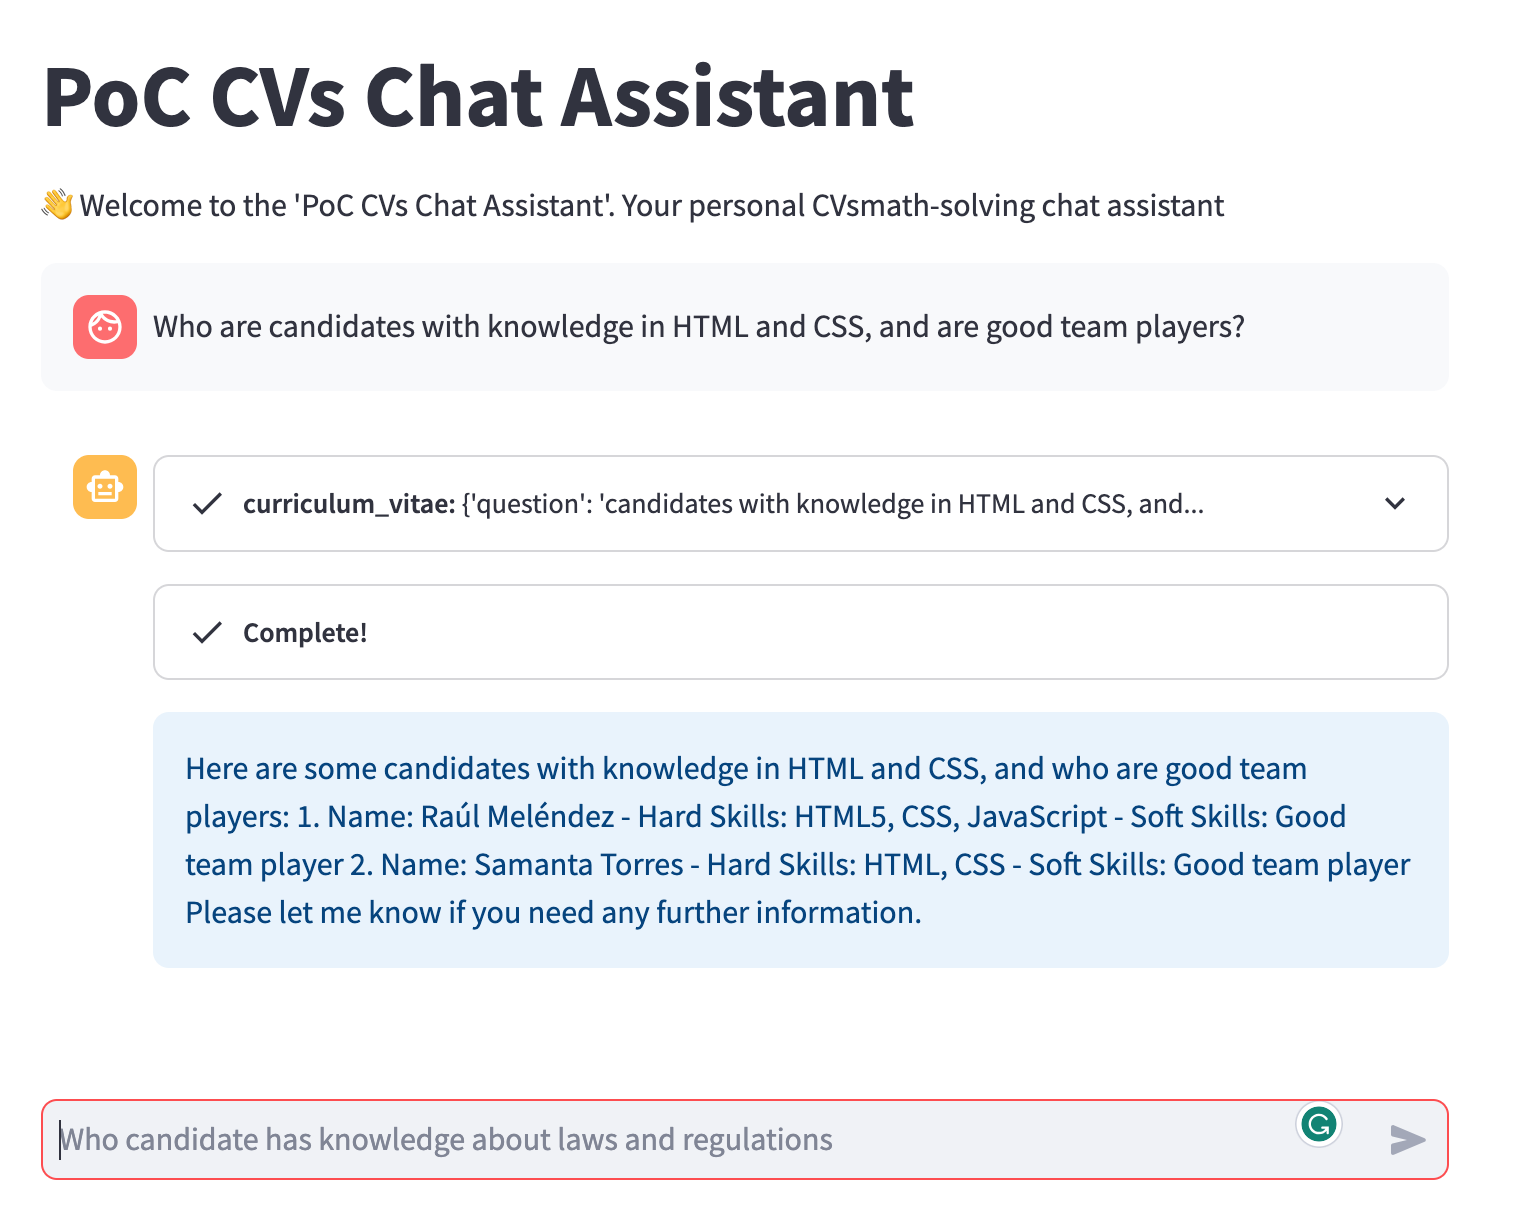

# Gradio

In [ ]:
# Import libraries
import os
import time
from dotenv import load_dotenv
import gradio as gr
import openai
from candidates import Result

# Import language-related modules
from langchain.embeddings.openai import OpenAIEmbeddings
from langchain.text_splitter import CharacterTextSplitter
from langchain.vectorstores import FAISS
from langchain.document_loaders import PyPDFLoader
from langchain.prompts import PromptTemplate
from langchain.output_parsers import PydanticOutputParser

load_dotenv()
openai.api_key = os.environ['OPENAI_API_KEY']

parser = PydanticOutputParser(pydantic_object=Result)
embeddings = OpenAIEmbeddings()
knowledge_database = FAISS.load_local('faiss_merged/', embeddings)
text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=0)


def get_completion(prompt: str, model: str = "gpt-3.5-turbo") -> str:
    messages = [{"role": "user", "content": prompt}]
    response = openai.ChatCompletion.create(
        model = model,
        messages=messages,
        temperature=0
    )
    return response.choices[0].message["content"]

def ask_to_chatbot(user_intent, file_paths, k=2):
    global faiss
    if file_paths:
        for path in file_paths:
            loader = PyPDFLoader(path)
            pages = loader.load_and_split()
            new_docs = text_splitter.split_documents(pages)
            doc_faiss = FAISS.from_documents(new_docs, embeddings)
            # add new documents into our db
            knowledge_database.merge_from(doc_faiss)

    docs = knowledge_database.similarity_search(user_intent, k=k)
    _prompt = PromptTemplate(
      template="Answer the user query, use the context:{context}.\n{format_instructions}\n{query}\n",
      input_variables=["query"],
      partial_variables={"format_instructions": parser.get_format_instructions(),\
                        "context": ' '.join([doc.page_content for doc in docs])},
      )
    _input = _prompt.format_prompt(query=user_intent)
    _answer = get_completion(_input.to_string())
    return _answer


with gr.Blocks() as app:
    gr.Markdown(
    """
# 👋 Welcome to the 'PoC CVs Chat Assistant'. 👋

## Your personal CV-solving chat assistant. 👨‍💻

## The pre-loaded knowledge database was ingested with this [CVs](https://drive.google.com/file/d/120VRjt801ngFObCqU6KgJKuleaKGEd1N/view?usp=sharing) 📁
    """)
    file_output = gr.File(file_count="multiple", file_types=["pdf"])
    chatbot = gr.Chatbot()
    msg = gr.Textbox()
    clear = gr.ClearButton([msg, chatbot])

    def respond(message, files, chat_history):
        # print(files)
        if files:
            files = [file.name for file in files]
        # print(files)
        bot_message = ask_to_chatbot(message, files, k=6)
        chat_history.append((message, bot_message))
        time.sleep(0.5)
        return "", chat_history

    msg.submit(respond, [msg, file_output, chatbot], [msg, chatbot])

# Launch the Gradio interface
app.launch(debug=True)

Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
Running on public URL: https://ba13a76f92fa11b5f2.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7863 <> https://ba13a76f92fa11b5f2.gradio.live


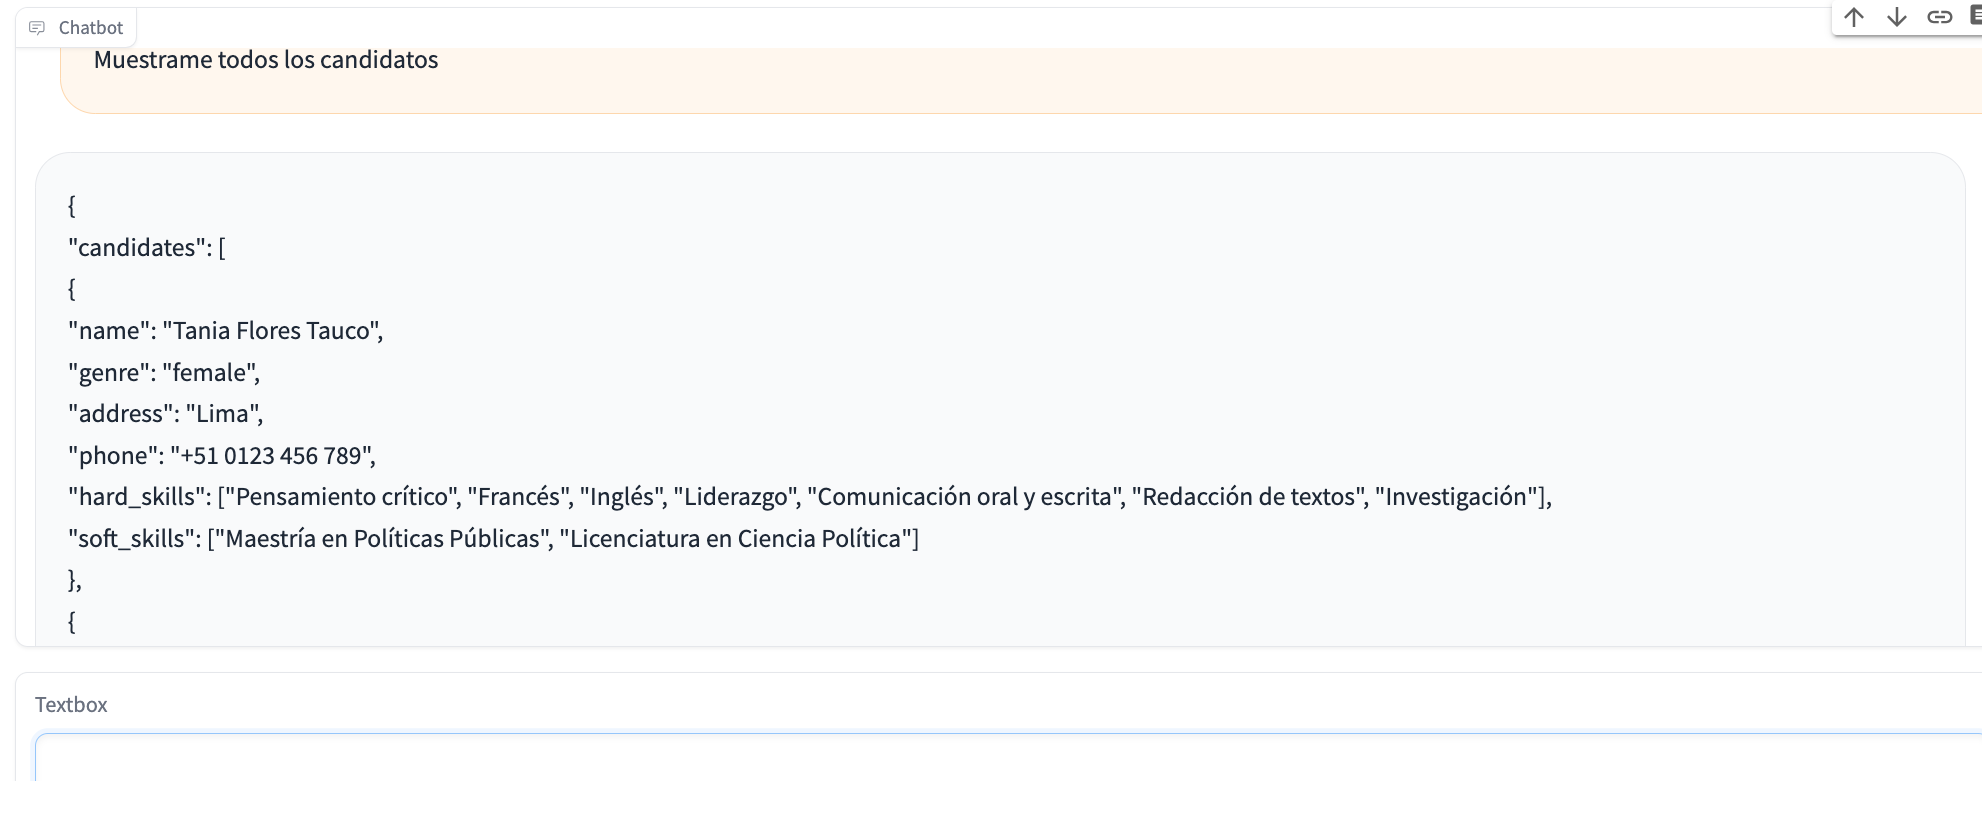